In [1]:
import os 
import cv2
import json
import re
import difflib
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import warnings 
warnings.filterwarnings('ignore')

from collections import defaultdict
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import losses
from tensorflow.keras import callbacks
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Conv2D, MaxPooling2D , GlobalAveragePooling2D,Dropout,BatchNormalization,Input,Flatten,Dense
from tensorflow.keras.applications import EfficientNetB0 ,DenseNet121,ResNet50

from IPython.display import clear_output
!pip install tf_explain
clear_output()

from keras.callbacks import Callback
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from tf_explain.core.grad_cam import GradCAM

from keras.metrics import MeanIoU

In [2]:
patients = pd.read_excel("/kaggle/input/datasets/sohailasayedmohamed/fibroscan-results/Patients.xlsx")
fibro = pd.read_csv("/kaggle/input/datasets/sohailasayedmohamed/fibroscan-results/fibroscan_results.csv")

def extract_id_from_image_path(path):
    filename = os.path.splitext(os.path.basename(path))[0]  
    base_id = re.sub(r'_\d+$', '', filename)
    return base_id


def extract_id_from_image_name(name):
    filename = os.path.splitext(name)[0]  
    base_id = re.sub(r'_fibroscan$', '', filename)
    return base_id


fibro["patient_id"] = fibro["image_name"].apply(extract_id_from_image_name)

fibro["patient_id"] = fibro["patient_id"].str.lower()

def norm(x):
    x = str(x).lower().strip()
    x = re.sub(r'\s+', '_', x)
    x = re.sub(r'_+', '_', x)
    return x

def extract_patient_id(img_name):
    base = re.sub(r'\.(jpg|jpeg|png)$', '', img_name, flags=re.I)
    base = re.sub(r'_fibroscan$', '', base, flags=re.I)
    return norm(base)

def extract_name_only(img_name):
    base = re.sub(r'\.(jpg|jpeg|png)$', '', img_name, flags=re.I)
    base = re.sub(r'_fibroscan$', '', base, flags=re.I)
    base = re.sub(r'^organized_dataset\d+_', '', base, flags=re.I)
    base = re.sub(r'_grade_?\d+$', '', base, flags=re.I)
    return norm(base)

fibro["patient_id"] = fibro["image_name"].apply(extract_patient_id)
fibro["name_only"]  = fibro["image_name"].apply(extract_name_only)
patients["name_only"] = patients["Name"].apply(norm)

patients_names = patients["name_only"].tolist()
name_map = {}
for fname in fibro["name_only"].unique():
    matches = difflib.get_close_matches(fname, patients_names, n=1, cutoff=0.7)
    name_map[fname] = matches[0] if matches else None

fibro["patients_name_match"] = fibro["name_only"].map(name_map)
fibro_clinical = pd.merge(
    fibro, patients,
    left_on="patients_name_match", right_on="name_only",
    how="left", suffixes=("", "_patient")
)

print("NUM OF Row fibro:", len(fibro))
print("NOT APPLY", fibro_clinical["Name"].isna().sum(), "ROW")
print(fibro_clinical.loc[fibro_clinical["Name"].isna(), "image_name"].tolist())

NUM OF Row fibro: 142
NOT APPLY 3 ROW
['organized_dataset3_EMAIL_ERENE_fibroscan.jpeg', 'organized_dataset5_email erene.jpeg', 'organized_dataset3_mona_zeinelabdin_fibroscan.jpeg']


In [3]:
df = fibro_clinical.copy()

In [4]:
df.columns

Index(['image_name', 'stage_fibrosis', 'stage_steatosis', 'Unnamed: 3',
       'patient_id', 'name_only', 'patients_name_match', 'Name', 'Gender',
       'Age', 'DM', 'HTN', 'BMI', 'waist circumference (cm)', 'triglceride',
       'HDL', 'cholesterol', 'INR', 'FBG', 'HBAIC', 'ALT', 'AST', 'Albumin',
       'Bilubin', 'weight in KG', 'height in cm ', 'Height *2',
       'Height in meter ', 'virology', 'MASLD', 'name_only_patient'],
      dtype='object')

In [5]:
df.drop('Unnamed: 3',axis=1, inplace=True)
df.dropna(inplace=True)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Age,BMI,waist circumference (cm),triglceride,HDL,cholesterol,INR,FBG,HBAIC,ALT,AST,Albumin,weight in KG,height in cm,Height *2,Height in meter
count,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000
mean,45.471014,28.223266,84.130435,231.804348,42.739130,178.673913,0.963043,114.833333,6.350000,30.753623,29.413043,3.527536,74.891304,161.666667,33.247372,2.260435
std,13.558304,4.522949,4.871826,790.593521,15.490192,60.191442,0.146445,28.822027,1.608338,34.320476,21.082296,0.498284,9.395359,5.743080,253.491040,5.323833
min,18.000000,0.033081,74.000000,30.000000,13.000000,53.000000,0.460000,79.000000,4.500000,3.000000,6.000000,1.600000,60.000000,150.000000,2.250000,1.500000
25%,37.250000,26.562500,81.000000,95.000000,35.000000,143.000000,0.900000,95.250000,5.225000,15.000000,16.250000,3.300000,70.000000,158.000000,2.496400,1.580000
50%,47.500000,27.943098,84.000000,130.000000,42.000000,163.500000,0.995000,110.000000,5.800000,21.500000,22.000000,3.500000,74.500000,160.000000,2.560000,1.600000
75%,60.000000,30.311620,87.000000,189.000000,46.000000,200.750000,1.000000,121.000000,6.800000,31.750000,36.750000,3.900000,80.000000,165.000000,2.747325,1.657500
max,72.000000,42.530769,105.000000,9200.000000,160.000000,500.000000,1.800000,221.000000,13.000000,251.000000,128.000000,4.900000,130.000000,189.000000,2116.000000,46.000000


In [8]:
df.describe(include='O')

,image_name,stage_fibrosis,stage_steatosis,patient_id,name_only,patients_name_match,Name,Gender,DM,HTN,Bilubin,virology,MASLD,name_only_patient
count,138,138,138,138,138,138,138,138,138,138,138,138,138,138
unique,138,3,4,138,121,119,119,2,2,3,103,1,2,119
top,organized_dataset1_Amr_abdel_moniem_fibroscan.jpg,F0-F1 (No/minimal fibrosis),S0 (Normal),organized_dataset1_amr_abdel_moniem,mohamed_ahmed_genegy,nagat_ahmed,Nagat ahmed,female,no,yes,0.8/0.4,negative,True,nagat_ahmed
freq,1,84,96,1,2,2,2,112,97,61,4,138,80,2


In [9]:
df.columns

Index(['image_name', 'stage_fibrosis', 'stage_steatosis', 'patient_id',
       'name_only', 'patients_name_match', 'Name', 'Gender', 'Age', 'DM',
       'HTN', 'BMI', 'waist circumference (cm)', 'triglceride', 'HDL',
       'cholesterol', 'INR', 'FBG', 'HBAIC', 'ALT', 'AST', 'Albumin',
       'Bilubin', 'weight in KG', 'height in cm ', 'Height *2',
       'Height in meter ', 'virology', 'MASLD', 'name_only_patient'],
      dtype='object')

> # ***Select important features***

In [10]:
df.drop([
    'image_name',
    'patient_id',
    'name_only', 
    'patients_name_match', 
    'Name', 
    'Gender',
    'name_only_patient',
    'stage_steatosis'
],axis=1,inplace=True)

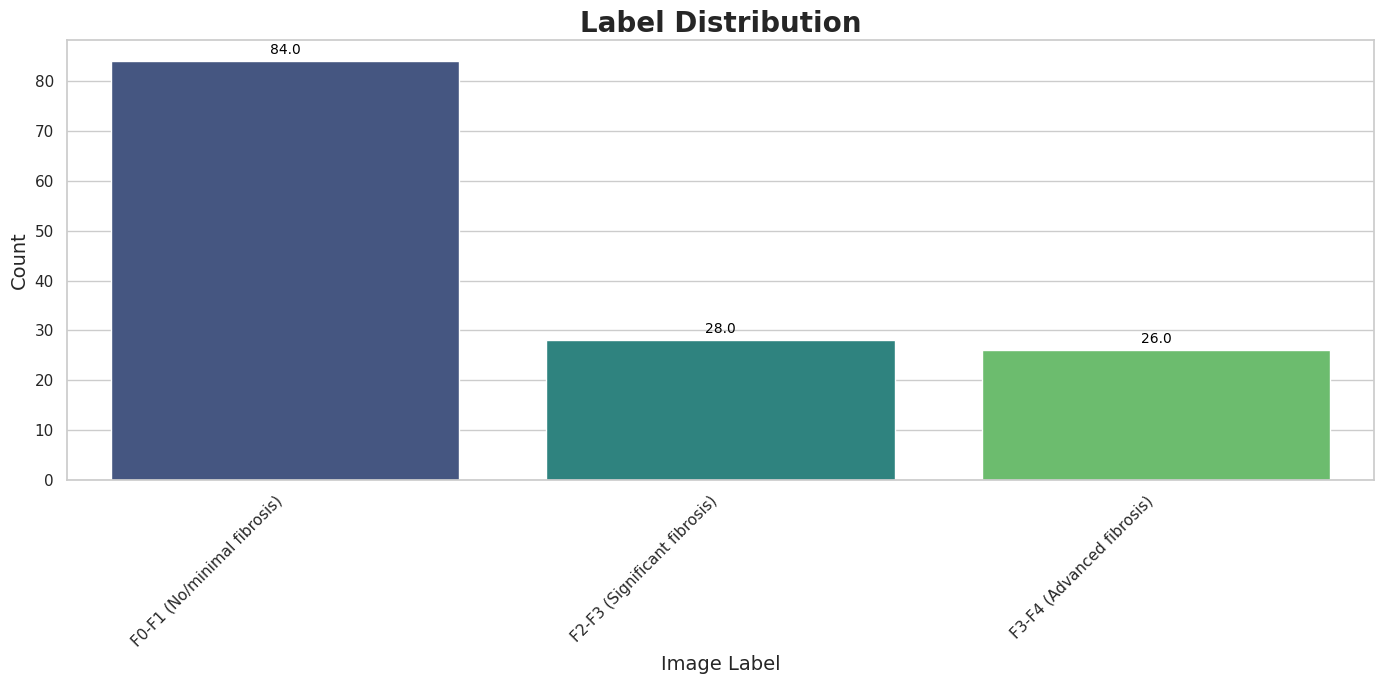

In [11]:
sns.set(style="whitegrid")
plt.figure(figsize=(14, 7))
ax = sns.countplot(data=df, x='stage_fibrosis', palette='viridis', order=df['stage_fibrosis'].value_counts().index)

plt.title("Label Distribution", fontsize=20, fontweight='bold')
plt.xlabel("Image Label", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 8),
                textcoords='offset points')
plt.tight_layout()
plt.show()

> # ***Data Augmentation*** 

In [12]:
# Separate classes
df_F0 = df[df['stage_fibrosis']=='F0-F1 (No/minimal fibrosis)']
df_F2 = df[df['stage_fibrosis']=='F2-F3 (Significant fibrosis)']
df_F3 = df[df['stage_fibrosis']=='F3-F4 (Advanced fibrosis)']

# Check imbalance
print(f"size of Class(0): {len(df_F0)} | size of Class(1): {len(df_F2)} | size of Class(2): {len(df_F3)}")

size of Class(0): 84 | size of Class(1): 28 | size of Class(2): 26


In [13]:
samples_needed = len(df_F0) - len(df_F2) 
samples_needed

56

In [14]:
numeric_cols = df.select_dtypes('number')
samples      = df_F2.sample(n=samples_needed,replace=True,random_state=42)
augmented    = samples.copy()


# Add small Gaussian noise
for col in numeric_cols:
    augmented[col] += np.random.normal(0,df[col].std(),size=samples_needed)


df = pd.concat([df,augmented],ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [15]:
samples_needed = len(df_F0) - len(df_F3) 
samples_needed

58

In [16]:
numeric_cols = df.select_dtypes('number')
samples      = df_F3.sample(n=samples_needed,replace=True,random_state=42)
augmented    = samples.copy()


# Add small Gaussian noise
for col in numeric_cols:
    augmented[col] += np.random.normal(0,df[col].std(),size=samples_needed)


df = pd.concat([df,augmented],ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

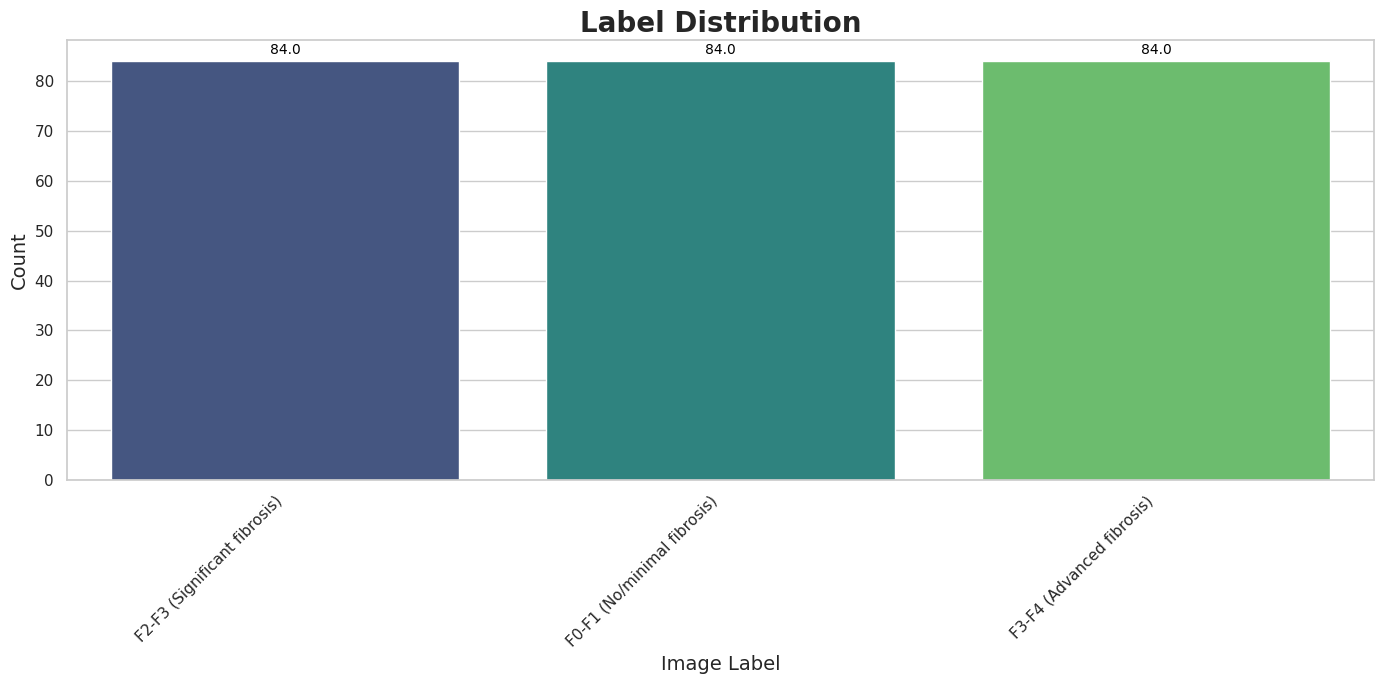

In [17]:
sns.set(style="whitegrid")
plt.figure(figsize=(14, 7))
ax = sns.countplot(data=df, x='stage_fibrosis', palette='viridis', order=df['stage_fibrosis'].value_counts().index)

plt.title("Label Distribution", fontsize=20, fontweight='bold')
plt.xlabel("Image Label", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 8),
                textcoords='offset points')
plt.tight_layout()
plt.show()

> # ***Label Encoder*** 

In [18]:
label_encoders = {}
categorical_cols= df.select_dtypes(include="object")
for col in categorical_cols:

    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [19]:
df.shape

(252, 22)

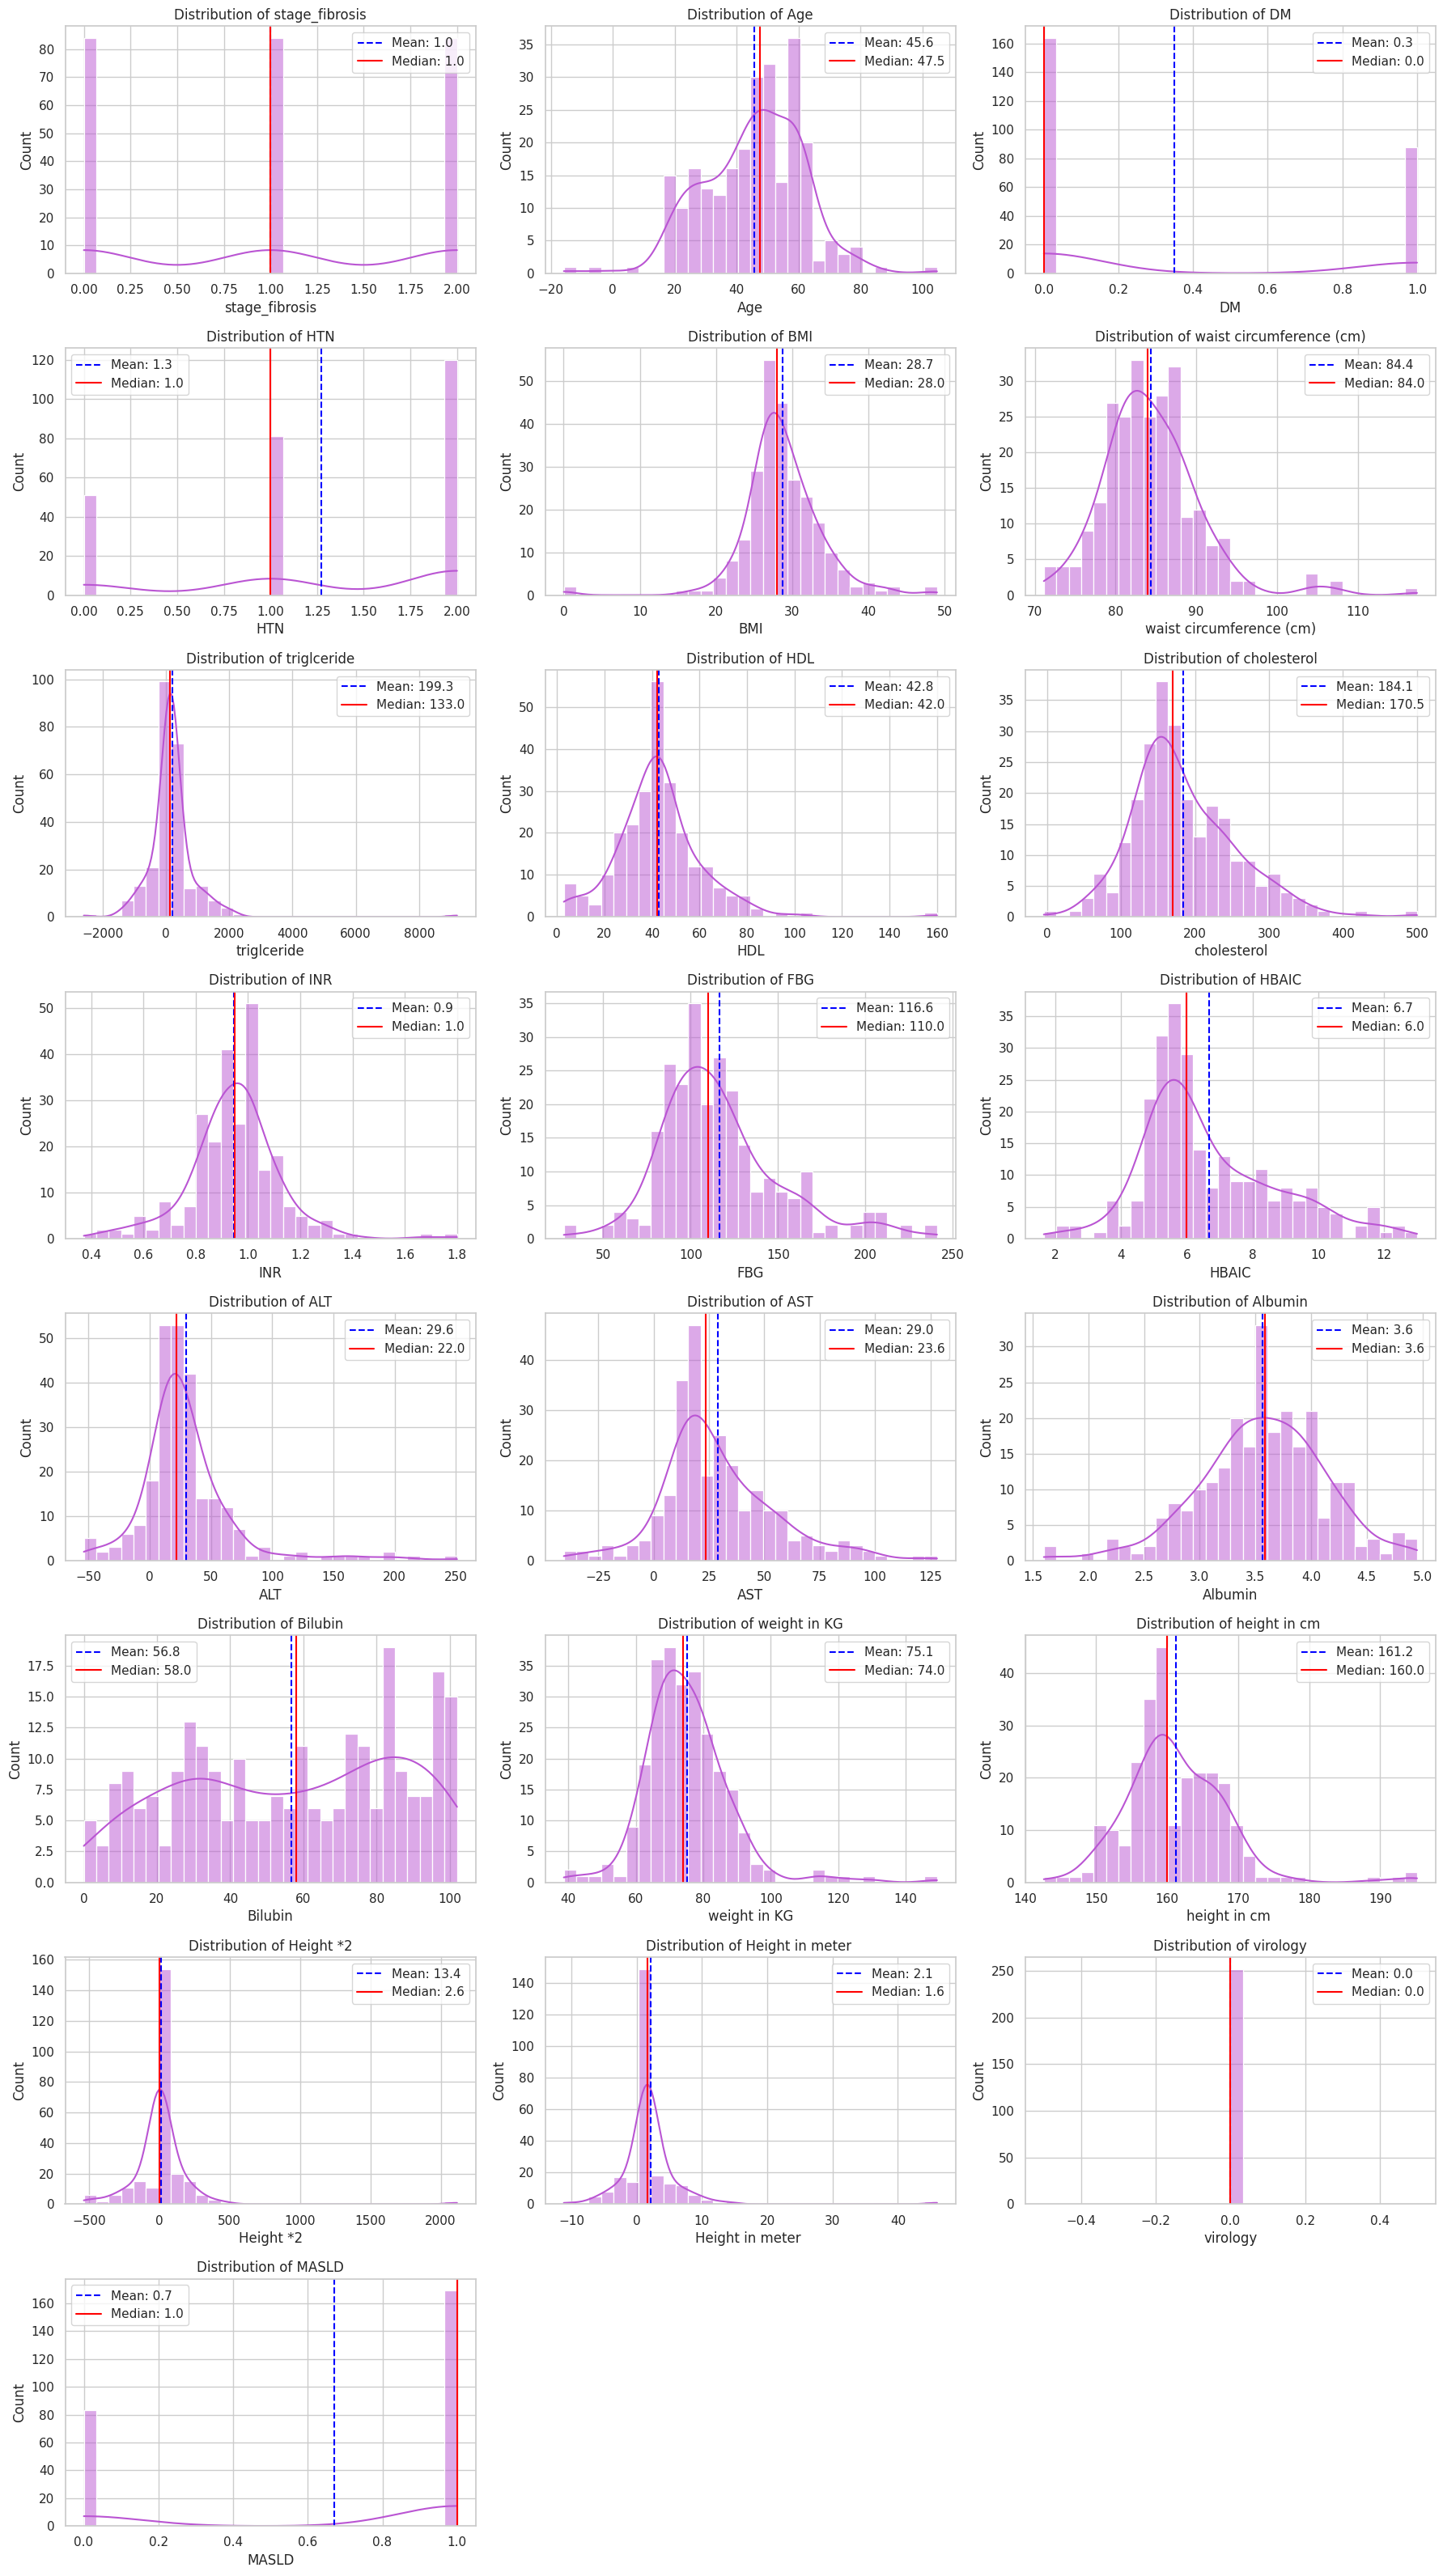

In [20]:
n_cols = 3
n_rows = (len(df.columns[:22]) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()


for i, col in enumerate(df.columns[:22]):
    sns.histplot(x=df[col], ax=axes[i], kde=True, bins=30,color='mediumorchid')


    mean_val = df[col].mean()
    median_val = df[col].median()


    axes[i].axvline(mean_val, color='blue', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='red', linestyle='-', label=f'Median: {median_val:.1f}')


    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend()


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [21]:
standard_scaler = StandardScaler()
df[numeric_cols.columns] = standard_scaler.fit_transform(df[numeric_cols.columns])

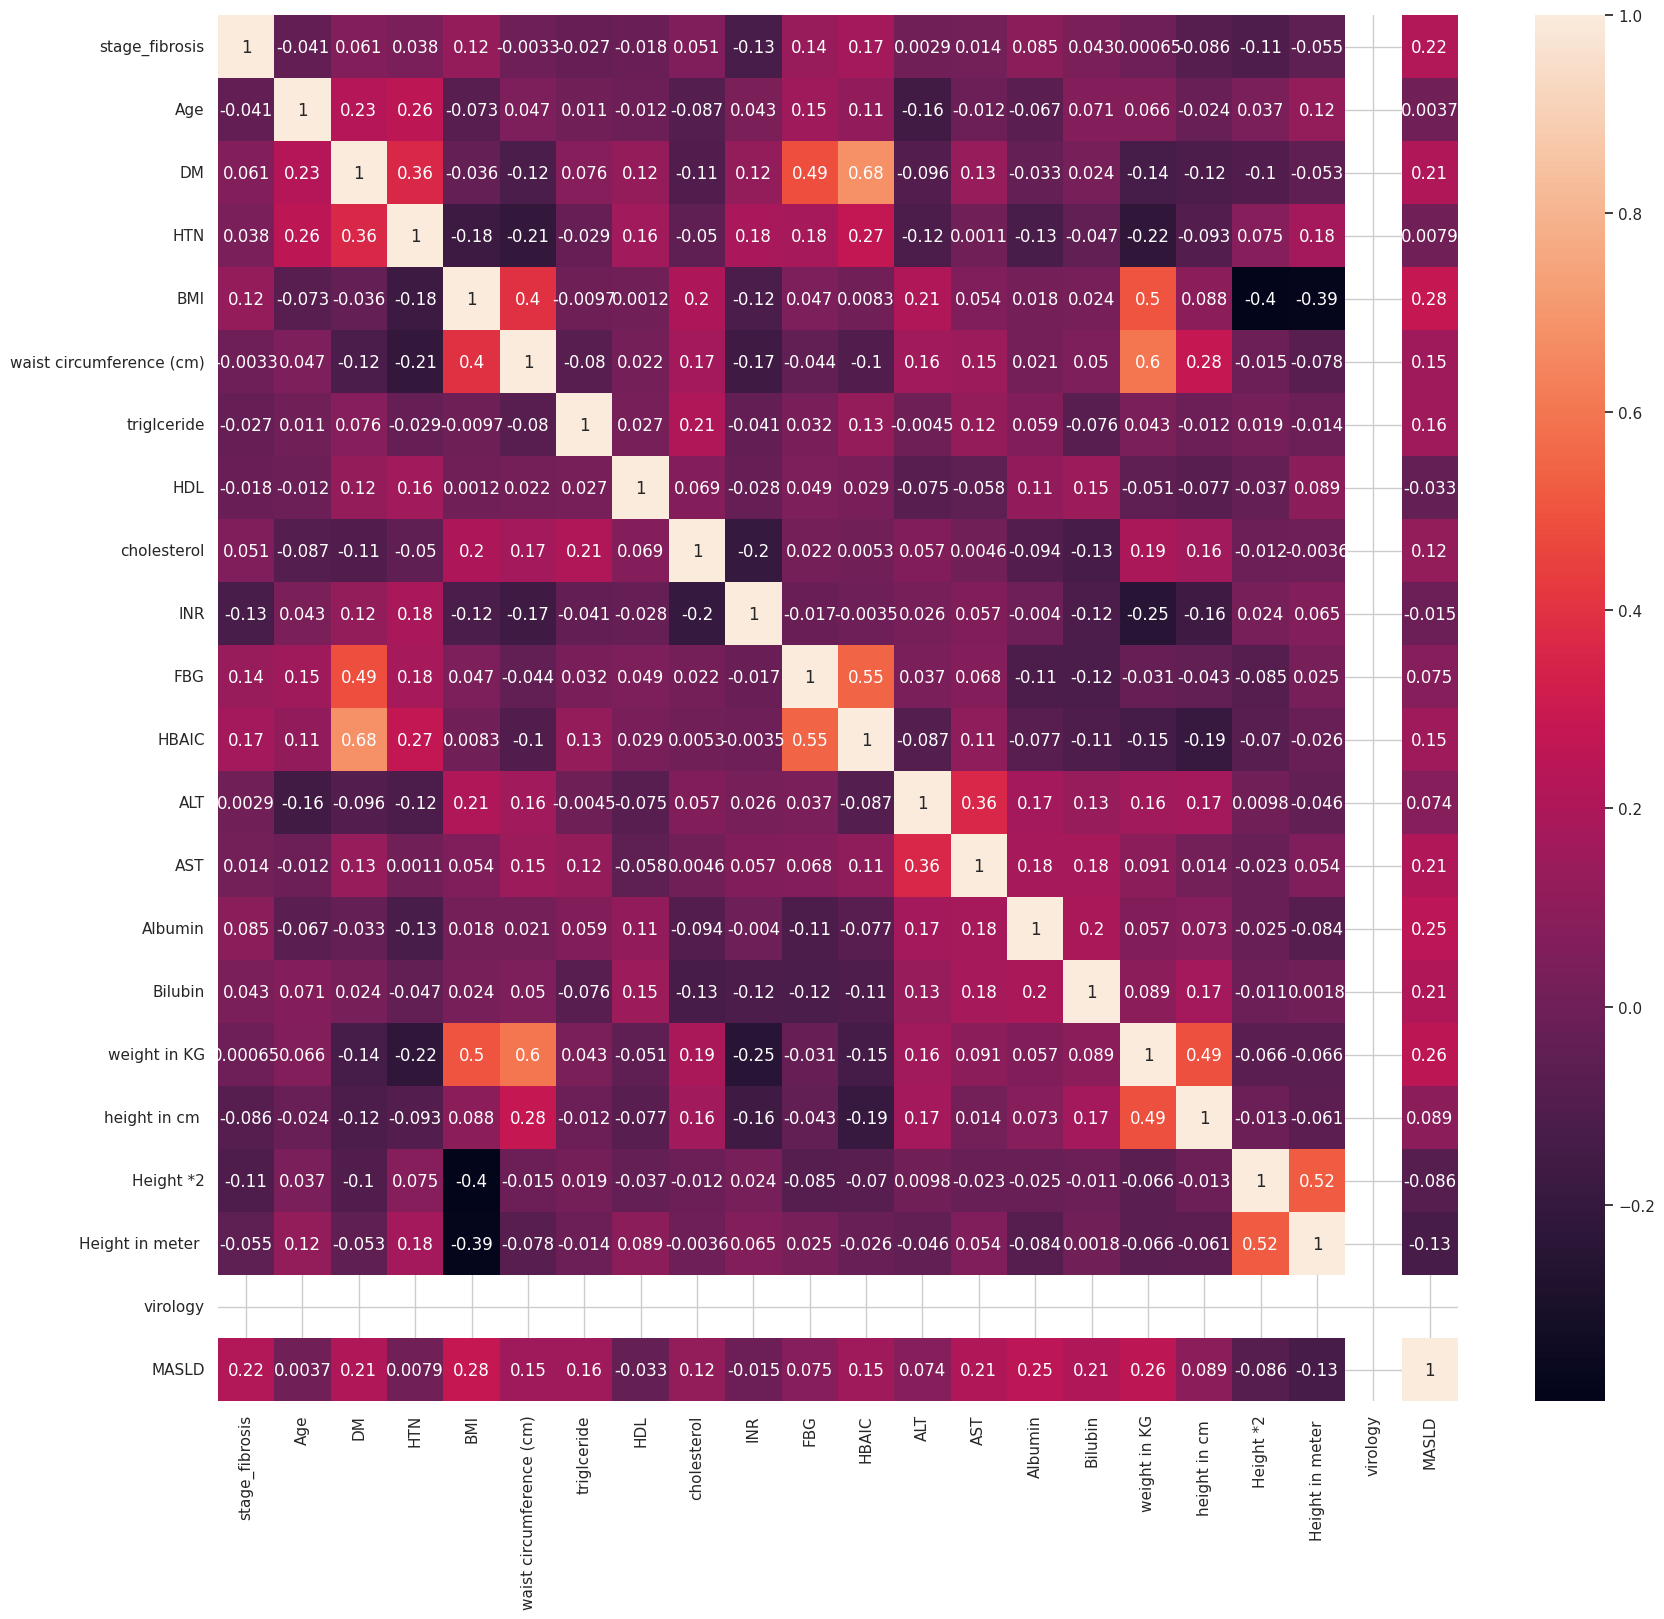

In [22]:
plt.figure(figsize=(20,18))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [23]:
X=df.drop(['virology','stage_fibrosis'],axis=1)
y = df['stage_fibrosis']

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,shuffle=True,random_state=42,stratify=df['stage_fibrosis'])

In [25]:
print(f"{' Training Features:':<25} {X_train.shape}")
print(f"{' Testing Features:':<25} {X_test.shape}")
print(f"{' Training Labels:':<25} {y_train.shape}")
print(f"{' Testing Labels:':<25} {y_test.shape}")

 Training Features:       (226, 20)
 Testing Features:        (26, 20)
 Training Labels:         (226,)
 Testing Labels:          (26,)


In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , StackingClassifier
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

param_grids = {
    'Decision Tree' : {'max_depth':[3,4,5,7,12,None]},
    'Random Forest'       : {'n_estimators':[50,100,200],'max_depth':[3,4,5,7,12,None]},
    'K_Nearsest_Neighbors': {'n_neighbors':[3,5,7]},
    'XGBoost'             : {'n_estimators':[50,100,200],'max_depth':[3,4,5,7,12,None],'learning_rate':[0.01,0.1,1]},
    'Logistic Regression' : {'C':[0.01,0.1,1]}# regulalization
}

models = {
    'Decision Tree' : DecisionTreeClassifier(),
    'Random Forest'       : RandomForestClassifier() ,
    'K_Nearsest_Neighbors': KNeighborsClassifier(),
    'XGBoost'             : XGBClassifier(),
    'Logistic Regression' : LogisticRegression()
}

# fit model hyper prameter tuning 
for name , model in models.items():
    grid_search = GridSearchCV(model,param_grids[name],cv=5,scoring='accuracy')
    grid_search.fit(X_train,y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    report = classification_report(y_test,y_pred)
    print(f'{name} Classification report :\n{report}\nBest Parameters:{grid_search.best_params_}\n')

Decision Tree Classification report :
              precision    recall  f1-score   support

           0       0.62      1.00      0.76         8
           1       1.00      0.33      0.50         9
           2       0.60      0.67      0.63         9

    accuracy                           0.65        26
   macro avg       0.74      0.67      0.63        26
weighted avg       0.74      0.65      0.63        26

Best Parameters:{'max_depth': 3}

Random Forest Classification report :
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         8
           1       0.75      0.67      0.71         9
           2       0.67      0.44      0.53         9

    accuracy                           0.69        26
   macro avg       0.69      0.70      0.68        26
weighted avg       0.70      0.69      0.68        26

Best Parameters:{'max_depth': None, 'n_estimators': 200}

K_Nearsest_Neighbors Classification report :
              precision  

In [27]:
model =  XGBClassifier(learning_rate= 0.1, max_depth= 3, n_estimators= 100)
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [28]:
y_pred = model.predict(X_test)

In [29]:
print(model.score(X_train,y_train))
print(model.score(X_test,y_test))

1.0
0.7307692307692307


In [30]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         8
           1       0.83      0.56      0.67         9
           2       0.75      0.67      0.71         9

    accuracy                           0.73        26
   macro avg       0.75      0.74      0.72        26
weighted avg       0.75      0.73      0.72        26



In [31]:
class_names = [
    "F0-F1",
    "F2-F3",
    "F3-F4"
]

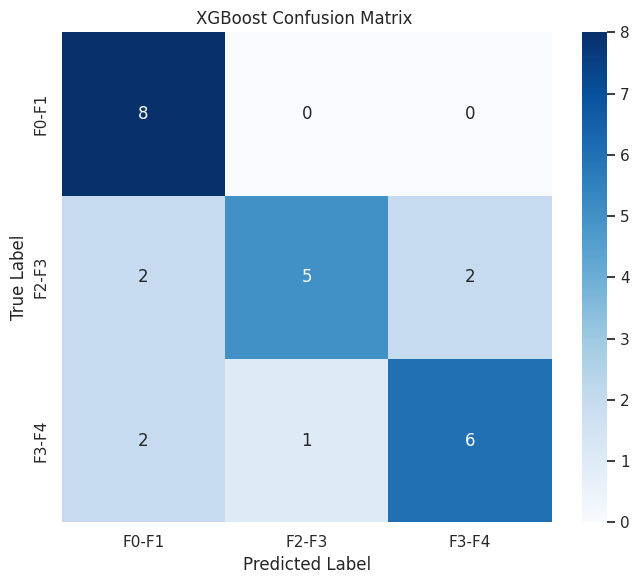

In [32]:
con = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    con,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('XGBoost Confusion Matrix ')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()

plt.savefig(
    "fibrosis_XGBoost_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
import pickle

pickle.dump(model,open('XGboost_fibrosis.pickle','wb'))

In [34]:
import joblib

# Save Label Encoders
joblib.dump(
    label_encoders,
    "fibrosis_label_encoders.pkl"
)

# Save Standard Scaler
joblib.dump(
    standard_scaler,
    "fibrosis_standard_scaler.pkl"
)

print("Label Encoders and Standard Scaler saved successfully!")

Label Encoders and Standard Scaler saved successfully!
